Processing station: 8635750...
Processing station: 8639348...
Processing station: 8638610...
Processing station: 8638901...
Processing station: 8632200...
Processing station: 8637689...
Processing station: 8571421...
Processing station: 8636580...
Processing station: 8577330...
Processing station: 8635027...
Processing station: 8571892...
Processing station: 8594900...
Processing station: 8575512...
Processing station: 8573364...
Processing station: 8574680...
Processing station: 8573927...


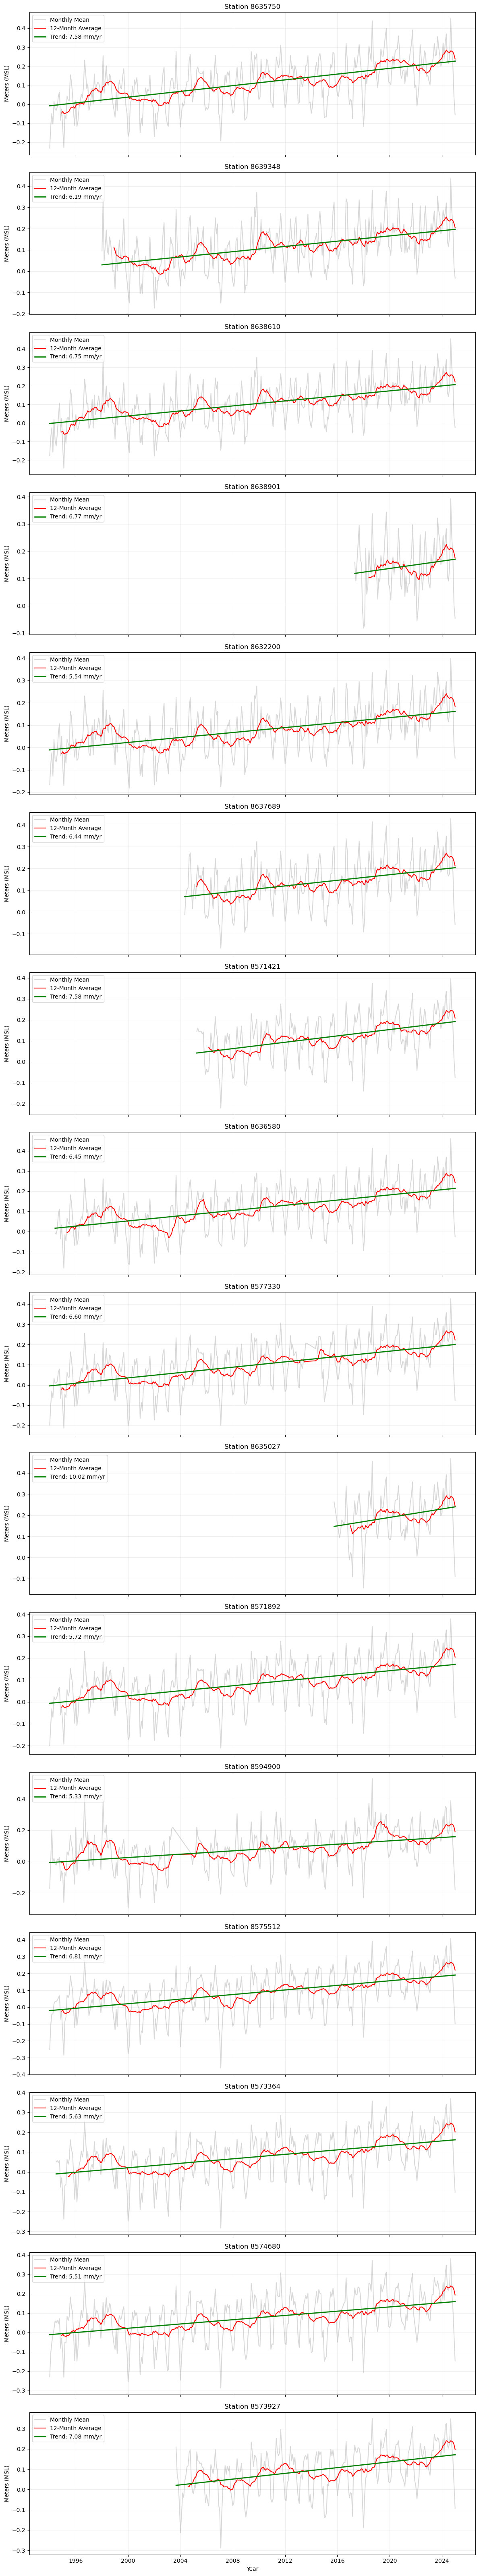


--- Summary of Relative Sea Level Rise Rates ---
Station 8635750: 7.58 mm/year
Station 8639348: 6.19 mm/year
Station 8638610: 6.75 mm/year
Station 8638901: 6.77 mm/year
Station 8632200: 5.54 mm/year
Station 8637689: 6.44 mm/year
Station 8571421: 7.58 mm/year
Station 8636580: 6.45 mm/year
Station 8577330: 6.60 mm/year
Station 8635027: 10.02 mm/year
Station 8571892: 5.72 mm/year
Station 8594900: 5.33 mm/year
Station 8575512: 6.81 mm/year
Station 8573364: 5.63 mm/year
Station 8574680: 5.51 mm/year
Station 8573927: 7.08 mm/year


In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.stats import linregress

# --- 1. SETUP ---
# Input your station IDs in this list
stations = ["8635750", "8639348", "8638610", "8638901", "8632200", "8637689", "8571421",
           "8636580", "8577330", "8635027", "8571892", "8594900", "8575512", "8573364", 
           "8574680", "8573927"] 

# We will store the calculated rates in this dictionary to compare them later
station_results = {}

# Create one big figure to hold all the plots (Subplots)
fig, axes = plt.subplots(nrows=len(stations), ncols=1, figsize=(12, 4 * len(stations)), sharex=True)

# --- 2. THE MULTI-STATION LOOP ---
for i, station_id in enumerate(stations):
    print(f"Processing station: {station_id}...")
    
    # Setting the 'filters' for our data request (station changes each loop)
    params = {
        "begin_date": "19940101",
        "end_date": "20241231",
        "station": station_id,
        "product": "monthly_mean",
        "datum": "MSL",
        "units": "metric",
        "time_zone": "lst_ldt",
        "format": "json"
    }

    try:
        # Request and Load Data
        response = requests.get("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter", params=params)
        data = response.json()
        df = pd.DataFrame(data['data'])

        # Data Cleaning
        df['timestamp'] = pd.to_datetime(df['year'] + "-" + df['month'])
        df['sea_level'] = pd.to_numeric(df['MSL'], errors='coerce')
        df.set_index('timestamp', inplace=True)
        df = df[['sea_level']].dropna()

        # --- 3. TRENDLINE CALCULATION ---
        # We need numerical x-values (ordinals) for the math
        x = df.index.map(pd.Timestamp.toordinal)
        y = df['sea_level']
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        # Convert slope (rise per day) to mm per year (365.25 days)
        rate_mm_yr = slope * 365.25 * 1000
        station_results[station_id] = rate_mm_yr

        # --- 4. VISUALIZATION ---
        ax = axes[i] # Select the specific subplot for this station
        
        # Plot raw data and rolling average
        ax.plot(df.index, df['sea_level'], label='Monthly Mean', alpha=0.3, color='gray')
        ax.plot(df.index, df['sea_level'].rolling(window=12).mean(), label='12-Month Average', color='red')
        
        # Plot the trendline
        ax.plot(df.index, intercept + slope * x, color='green', linewidth=2, 
                label=f'Trend: {rate_mm_yr:.2f} mm/yr')

        ax.set_title(f"Station {station_id}")
        ax.set_ylabel("Meters (MSL)")
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.2)

    except Exception as e:
        print(f"Could not process station {station_id}: {e}")

# Global formatting
plt.xlabel("Year")
plt.tight_layout()
plt.savefig('Chesapeake_Bay_MultiStation_Analysis.png')
plt.show()

# --- 5. FINAL COMPARISON ---
print("\n--- Summary of Relative Sea Level Rise Rates ---")
for s_id, rate in station_results.items():
    print(f"Station {s_id}: {rate:.2f} mm/year")

Processing: Lewisetta, VA (Lat: 37.9961, Lon: -76.4644)...
Processing: Money Point, VA (Lat: 36.778194, Lon: -76.301865)...
Processing: Sewells Point, VA (Lat: 36.94278, Lon: -76.32861)...
Processing: CBBT, Chesapeake Channel, VA (Lat: 37.0329, Lon: -76.0833)...
Processing: Kiptopeke, VA (Lat: 37.1652, Lon: -75.9884)...
Processing: Yorktown USCG Training Center, VA (Lat: 37.2265, Lon: -76.478806)...
Processing: Bishops Head, MD (Lat: 38.22, Lon: -76.0383)...
Processing: Windmill Point, VA (Lat: 37.6155, Lon: -76.28978)...
Processing: Solomons Island, MD (Lat: 38.3167, Lon: -76.4517)...
Processing: Dahlgren, VA (Lat: 38.31975, Lon: -77.0366)...
Processing: Cambridge, MD (Lat: 38.5725, Lon: -76.06167)...
Processing: Washington, DC (Lat: 38.873333, Lon: -77.02167)...
Processing: Annapolis, MD (Lat: 38.983883, Lon: -76.480034)...
Processing: Tolchester Beach, MD (Lat: 39.213444, Lon: -76.24455)...
Processing: Baltimore, MD (Lat: 39.266693, Lon: -76.57831)...
Processing: Chesapeake City, MD

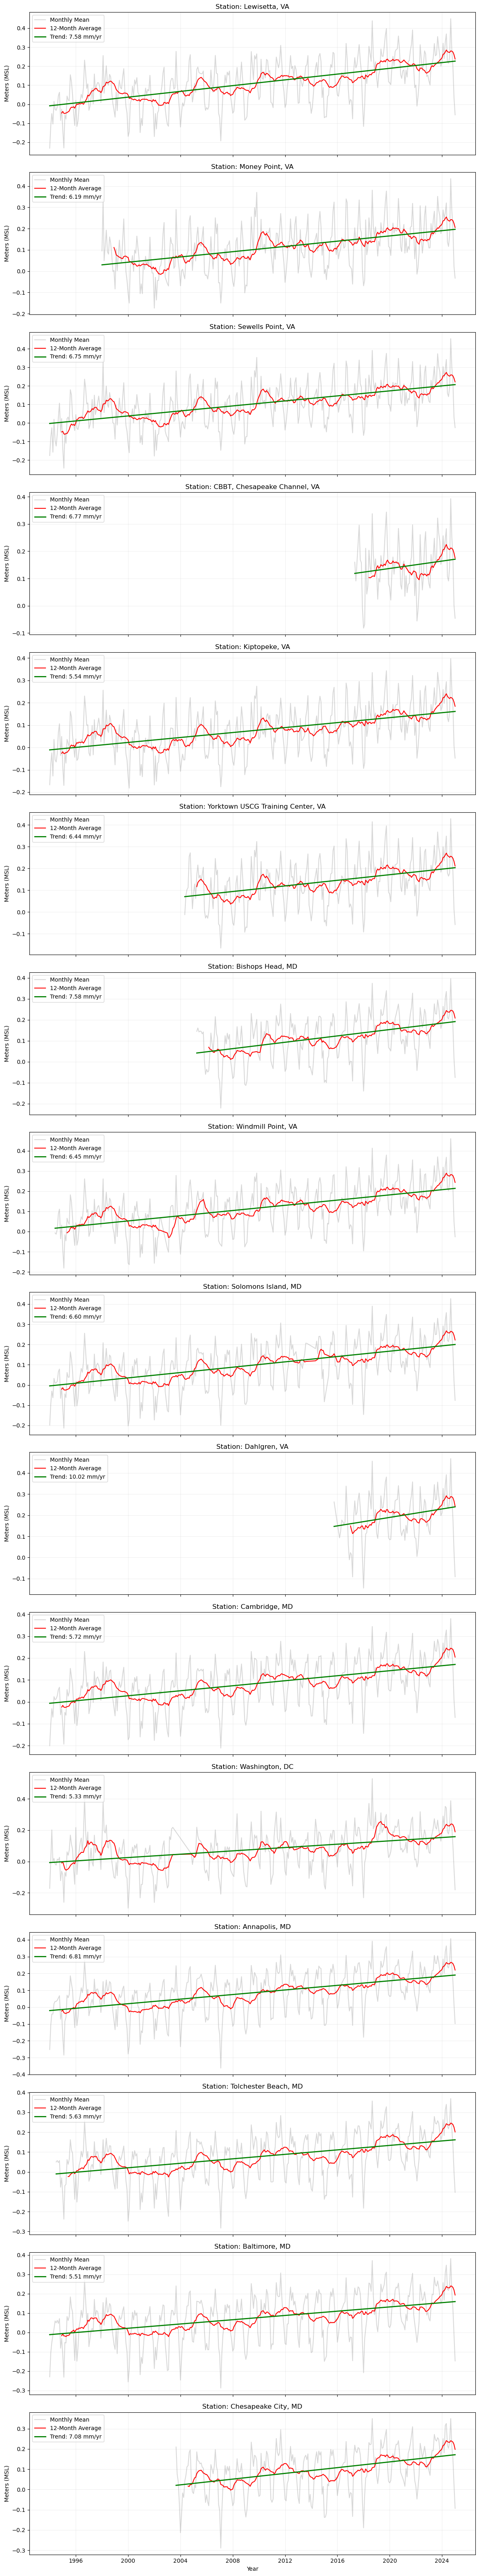


--- Summary Table (Ready for Mapping) ---
Station ID   | Name                                | Lat      | Lon      | Rate (mm/yr)
-------------------------------------------------------------------------------------
8635750      | Lewisetta, VA                       | 37.9961  | -76.4644 | 7.58
8639348      | Money Point, VA                     | 36.7782  | -76.3019 | 6.19
8638610      | Sewells Point, VA                   | 36.9428  | -76.3286 | 6.75
8638901      | CBBT, Chesapeake Channel, VA        | 37.0329  | -76.0833 | 6.77
8632200      | Kiptopeke, VA                       | 37.1652  | -75.9884 | 5.54
8637689      | Yorktown USCG Training Center, VA   | 37.2265  | -76.4788 | 6.44
8571421      | Bishops Head, MD                    | 38.2200  | -76.0383 | 7.58
8636580      | Windmill Point, VA                  | 37.6155  | -76.2898 | 6.45
8577330      | Solomons Island, MD                 | 38.3167  | -76.4517 | 6.60
8635027      | Dahlgren, VA                        | 38.3197  |

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# --- 1. SETUP ---
# Just the IDs are needed now; the API will find the names and locations
station_ids = ["8635750", "8639348", "8638610", "8638901", "8632200", "8637689", "8571421",
               "8636580", "8577330", "8635027", "8571892", "8594900", "8575512", "8573364", 
               "8574680", "8573927"] 

# This dictionary will store all metadata and results for your future map
station_data_summary = {}

# Create figure
fig, axes = plt.subplots(nrows=len(station_ids), ncols=1, figsize=(12, 4 * len(station_ids)), sharex=True)

# --- 2. THE MULTI-STATION LOOP ---
for i, station_id in enumerate(station_ids):
    try:
        # A. GET METADATA (Name, Lat, Lon)
        meta_url = f"https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations/{station_id}.json"
        meta_res = requests.get(meta_url)
        meta_res.raise_for_status()
        meta_json = meta_res.json()
        
        # Extract details from the first station entry in the list
        s_info = meta_json['stations'][0]
        s_name = f"{s_info['name']}, {s_info['state']}"
        s_lat = float(s_info['lat'])
        s_lon = float(s_info['lng'])
        
        print(f"Processing: {s_name} (Lat: {s_lat}, Lon: {s_lon})...")

        # B. GET SEA LEVEL DATA
        params = {
            "begin_date": "19940101",
            "end_date": "20241231",
            "station": station_id,
            "product": "monthly_mean",
            "datum": "MSL",
            "units": "metric",
            "time_zone": "lst_ldt",
            "format": "json"
        }
        
        data_res = requests.get("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter", params=params)
        data = data_res.json()

        if 'data' not in data:
            print(f"  ! No sea level data found for {s_name}.")
            continue

        df = pd.DataFrame(data['data'])
        df['timestamp'] = pd.to_datetime(df['year'] + "-" + df['month'])
        df['sea_level'] = pd.to_numeric(df['MSL'], errors='coerce')
        df.set_index('timestamp', inplace=True)
        df = df[['sea_level']].dropna()

        # --- 3. TRENDLINE CALCULATION ---
        x = df.index.map(pd.Timestamp.toordinal)
        y = df['sea_level']
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        rate_mm_yr = slope * 365.25 * 1000

        # Store everything for the Cartopy map later
        station_data_summary[station_id] = {
            "name": s_name,
            "lat": s_lat,
            "lon": s_lon,
            "rate": rate_mm_yr
        }

        # --- 4. VISUALIZATION ---
        ax = axes[i]
        ax.plot(df.index, df['sea_level'], label='Monthly Mean', alpha=0.3, color='gray')
        ax.plot(df.index, df['sea_level'].rolling(window=12).mean(), label='12-Month Average', color='red')
        ax.plot(df.index, intercept + slope * x, color='green', linewidth=2, 
                label=f'Trend: {rate_mm_yr:.2f} mm/yr')

        ax.set_title(f"Station: {s_name}")
        ax.set_ylabel("Meters (MSL)")
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.2)

    except Exception as e:
        print(f"Error processing station {station_id}: {e}")

# Global formatting
plt.xlabel("Year")
plt.tight_layout()
plt.savefig('Chesapeake_Bay_Analysis_with_Metadata.png')
plt.show()

# --- 5. FINAL COMPARISON ---
print("\n--- Summary Table (Ready for Mapping) ---")
print(f"{'Station ID':<12} | {'Name':<35} | {'Lat':<8} | {'Lon':<8} | {'Rate (mm/yr)'}")
print("-" * 85)
for s_id, info in station_data_summary.items():
    print(f"{s_id:<12} | {info['name']:<35} | {info['lat']:<8.4f} | {info['lon']:<8.4f} | {info['rate']:.2f}")

/opt/anaconda3/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


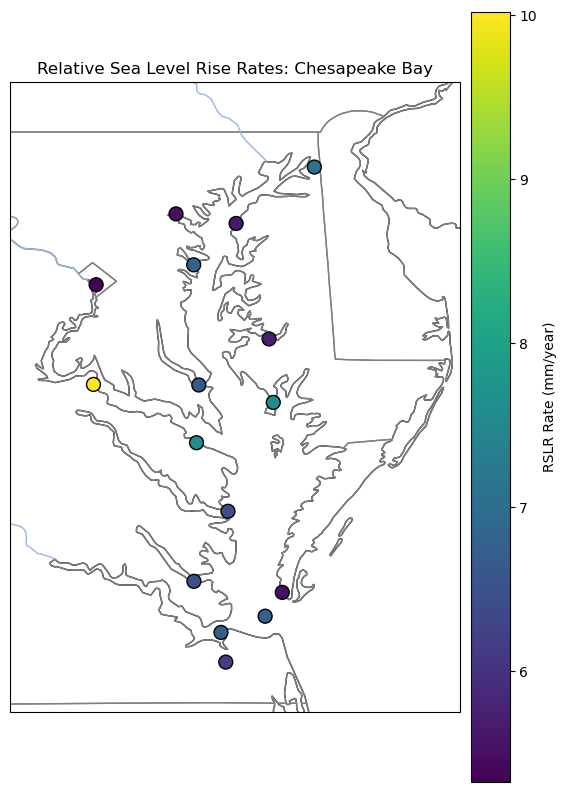

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# 1. Extract data from your existing dictionary
lons = [info['lon'] for info in station_data_summary.values()]
lats = [info['lat'] for info in station_data_summary.values()]
rates = [info['rate'] for info in station_data_summary.values()]

# 2. Setup the Map
fig = plt.figure(figsize=(7, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic details
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Set the extent to zoom into the Chesapeake Bay
ax.set_extent([-77.5, -75.0, 36.5, 40.0], crs=ccrs.PlateCarree())

# 3. Create the "Heatmap" Effect
# 'c' links the color to the rates, 'cmap' defines the heat scale (yellow to red)
scatter = ax.scatter(lons, lats, c=rates, cmap='viridis', s=100, 
                     edgecolor='black', transform=ccrs.PlateCarree(), zorder=5)

# Add a colorbar to explain the "heat"
cbar = plt.colorbar(scatter, orientation='vertical', pad=0.02, aspect=20)
cbar.set_label('RSLR Rate (mm/year)')

plt.title("Relative Sea Level Rise Rates: Chesapeake Bay")
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


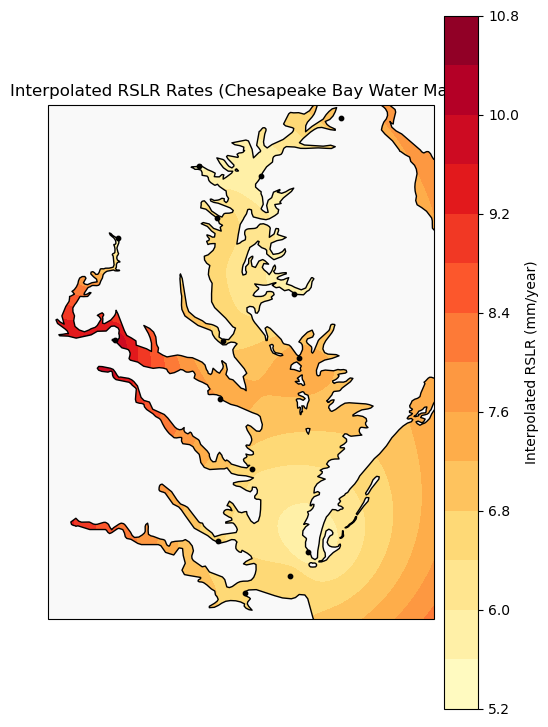

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import Rbf

# 1. Prepare the Data
lons = np.array([info['lon'] for info in station_data_summary.values()])
lats = np.array([info['lat'] for info in station_data_summary.values()])
rates = np.array([info['rate'] for info in station_data_summary.values()])

# 2. Create a dense grid for the interpolation
# We define the boundaries of the Chesapeake Bay
grid_lon = np.linspace(-77.5, -75.0, 200)
grid_lat = np.linspace(36.5, 40.0, 200)
lon_mesh, lat_mesh = np.meshgrid(grid_lon, grid_lat)

# 3. Perform the Interpolation (Rbf is smoother than griddata)
rbf = Rbf(lons, lats, rates, function='linear')
zi = rbf(lon_mesh, lat_mesh)

# 4. Plotting with the "Cookie Cutter" (Masking)
fig = plt.figure(figsize=(6, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add high-resolution land and color it to "cover" the heatmap
# 'zorder' is key: we put the land ABOVE the heatmap
land_feature = cfeature.NaturalEarthFeature(
    category='physical', name='land', scale='10m',
    facecolor='#f9f9f9', edgecolor='black'
)

# Plot the heatmap (contourf)
# We set a lower zorder so it sits behind the land
contour = ax.contourf(lon_mesh, lat_mesh, zi, levels=15, 
                     cmap='YlOrRd', transform=ccrs.PlateCarree(), zorder=1)

# Add the land on top to mask out the "bleeding"
ax.add_feature(land_feature, zorder=2)
ax.add_feature(cfeature.LAKES, facecolor='white', edgecolor='black', zorder=3)

# Add the original station points so people see the "real" data
ax.scatter(lons, lats, color='black', s=10, transform=ccrs.PlateCarree(), zorder=4)

# Set the view
ax.set_extent([-77.4, -75.3, 36.8, 39.6])

cbar = plt.colorbar(contour, pad=0.02)
cbar.set_label('Interpolated RSLR (mm/year)')

plt.title("Interpolated RSLR Rates (Chesapeake Bay Water Mask)")
plt.show()